# Model Evaluation

## Objective

Evaluate the trained SRCNN model on the validation dataset using quantitative metrics (PSNR, SSIM and MSE) and visualize qualitative reconstruction results.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [2]:
import matplotlib.pyplot as plt
import torch

from src.models.srcnn import SRCNN
from src.checkpoint import load_model

from src.dataloader import get_validation_loader

from src.metrics import (
    calculate_psnr,
    calculate_ssim
)

from src.utils.image_utils import tensor_to_image

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [4]:
validation_loader = get_validation_loader()

In [5]:
model = SRCNN()

model = load_model(
    model,
    "../results/checkpoints/srcnn_best.pth",
    device
)

c:\Users\aless\Documents\RetroSR-CNN\src\checkpoint.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filepath, map_location=device)


In [6]:
total_psnr = 0.0
total_ssim = 0.0
total_mse = 0.0

num_batches = 0

model.eval()

with torch.no_grad():

    for lr_batch, hr_batch in validation_loader:

        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)

        prediction = model(lr_batch)

        total_psnr += calculate_psnr(
            prediction,
            hr_batch
        )

        total_ssim += calculate_ssim(
            prediction,
            hr_batch
        )

        mse = torch.mean(
            (prediction - hr_batch) ** 2
        )

        total_mse += mse.item()

        num_batches += 1

In [7]:
average_psnr = total_psnr / num_batches
average_ssim = total_ssim / num_batches
average_mse = total_mse / num_batches

print(f"Average PSNR : {average_psnr:.2f} dB")
print(f"Average SSIM : {average_ssim:.4f}")
print(f"Average MSE  : {average_mse:.6f}")

Average PSNR : 28.27 dB
Average SSIM : 0.8851
Average MSE  : 0.001622


In [8]:
lr_batch, hr_batch = next(iter(validation_loader))

lr_batch = lr_batch.to(device)

with torch.no_grad():

    prediction = model(lr_batch)

In [9]:
lr_image = lr_batch[0].cpu()
prediction_image = prediction[0].cpu()
hr_image = hr_batch[0]

In [10]:
lr_image = tensor_to_image(lr_image)
prediction_image = tensor_to_image(prediction_image)
hr_image = tensor_to_image(hr_image)

<module 'torchvision.transforms' from 'c:\\Users\\aless\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\torchvision\\transforms\\__init__.py'>
<module 'torchvision.transforms' from 'c:\\Users\\aless\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\torchvision\\transforms\\__init__.py'>
<module 'torchvision.transforms' from 'c:\\Users\\aless\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\torchvision\\transforms\\__init__.py'>


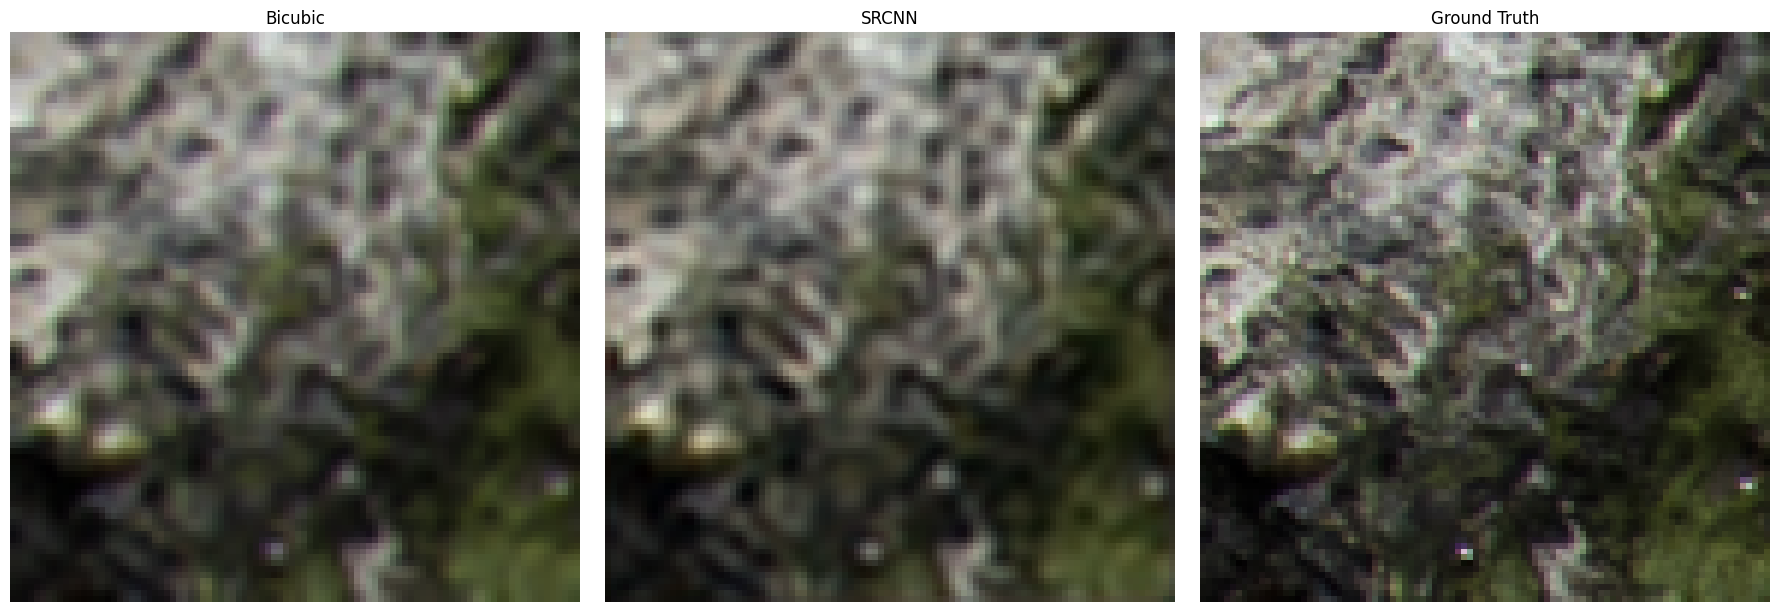

In [11]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(lr_image)
plt.title("Bicubic")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(prediction_image)
plt.title("SRCNN")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hr_image)
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()

plt.show()

In [12]:
print("=" * 35)
print("SRCNN Evaluation Results")
print("=" * 35)
print(f"Average PSNR : {average_psnr:.2f} dB")
print(f"Average SSIM : {average_ssim:.4f}")
print(f"Average MSE  : {average_mse:.6f}")
print("=" * 35)

SRCNN Evaluation Results
Average PSNR : 28.27 dB
Average SSIM : 0.8851
Average MSE  : 0.001622
